#Installing Libraries


In [ ]:
!pip install pandas numpy matplotlib seaborn sqlalchemy pymysql scikit-learn

#Data Import

In [ ]:
import pandas as pd

df = pd.read_csv('sample_data/styles.csv')
print("CSV file imported successfully!")
print("First 5 rows:")
display(df.head())
print(f"DataFrame shape: {df.shape}")


CSV file imported successfully!
First 5 rows:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,NaN,NaN
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,NaN,NaN
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,NaN,NaN
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,NaN,NaN
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,NaN,NaN


DataFrame shape: (44446, 12)


#Data Cleaning



data description

In [ ]:
print("\nDuplicate Rows:", df.duplicated().sum())
print("Summary Statistics:")
df.describe(include='all')


Duplicate Rows: 0
Summary Statistics:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
count,44446.000000,44446,44446,44446,44446,44431,44425,44445.000000,44129,44439,22,2
unique,NaN,5,7,45,143,46,4,NaN,8,31135,9,2
top,NaN,Men,Apparel,Topwear,Tshirts,Black,Summer,NaN,Casual,Lucera Women Silver Earrings,Cufflink and Pocket Square Combo Set,Love Flip-flops
freq,NaN,22165,21400,15405,7070,9732,21476,NaN,34414,82,14,1
mean,29692.631350,NaN,NaN,NaN,NaN,NaN,NaN,2012.805940,NaN,NaN,NaN,NaN
std,17048.234982,NaN,NaN,NaN,NaN,NaN,NaN,2.126401,NaN,NaN,NaN,NaN
min,1163.000000,NaN,NaN,NaN,NaN,NaN,NaN,2007.000000,NaN,NaN,NaN,NaN
25%,14770.250000,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN,NaN,NaN
50%,28609.500000,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN
75%,44678.750000,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN


In [ ]:
df.info()
print("\nNull Counts per Column:")
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44446 entries, 0 to 44445
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44446 non-null  int64  
 1   gender              44446 non-null  object 
 2   masterCategory      44446 non-null  object 
 3   subCategory         44446 non-null  object 
 4   articleType         44446 non-null  object 
 5   baseColour          44431 non-null  object 
 6   season              44425 non-null  object 
 7   year                44445 non-null  float64
 8   usage               44129 non-null  object 
 9   productDisplayName  44439 non-null  object 
 10  Unnamed: 10         22 non-null     object 
 11  Unnamed: 11         2 non-null      object 
dtypes: float64(1), int64(1), object(10)
memory usage: 4.1+ MB

Null Counts per Column:


,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,317
productDisplayName,7


col drop



In [ ]:
df = df.drop(columns=['productDisplayName','year','Unnamed: 10', 'Unnamed: 11'])
print("Columns removed successfully!")


Columns removed successfully!


Handling missing values


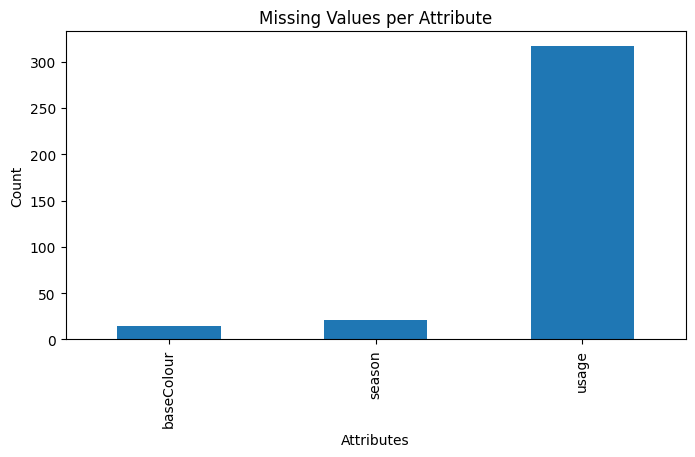

In [ ]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8,4))
missing.plot(kind='bar')
plt.title("Missing Values per Attribute")
plt.ylabel("Count")
plt.xlabel("Attributes")
plt.show()



In [ ]:
print("Value counts for 'baseColour' before filling missing values:")
df['baseColour'].value_counts(dropna=False)

Value counts for 'baseColour' before filling missing values:


,count
baseColour,
Black,9732
White,5540
Blue,4922
Brown,3494
Grey,2741
Red,2458
Green,2116
Pink,1861
Navy Blue,1791


In [ ]:
print("Value counts for 'season' before filling missing values:")
df['season'].value_counts(dropna=False)

Value counts for 'season' before filling missing values:


,count
season,
Summer,21476
Fall,11445
Winter,8519
Spring,2985
NaN,21


In [ ]:
print("\nValue counts for 'usage' before filling missing values:")
df['usage'].value_counts(dropna=False)


Value counts for 'usage' before filling missing values:


,count
usage,
Casual,34414
Sports,4025
Ethnic,3208
Formal,2359
NaN,317
Smart Casual,67
Party,29
Travel,26
Home,1


In [ ]:
print("Filling missing values in 'baseColour','season' and 'usage' with their modes...")
mode_baseColour = df['baseColour'].mode()[0]
df['baseColour'].fillna(mode_baseColour, inplace=True)
mode_season = df['season'].mode()[0]
df['season'].fillna(mode_season, inplace=True)
mode_usage = df['usage'].mode()[0]
df['usage'].fillna(mode_usage, inplace=True)
print(f"Missing values in 'baseColour' filled with '{mode_baseColour}'.")
print(f"Missing values in 'season' filled with '{mode_season}'.")
print(f"Missing values in 'usage' filled with '{mode_usage}'.")

Filling missing values in 'baseColour','season' and 'usage' with their modes...
Missing values in 'baseColour' filled with 'Black'.
Missing values in 'season' filled with 'Summer'.
Missing values in 'usage' filled with 'Casual'.


In [ ]:
print("\nNull Counts per Column after filling 'baseColour','season' and 'usage':")
df.isnull().sum()


Null Counts per Column after filling 'baseColour','season' and 'usage':


,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
usage,0


### Text Normalization

I am normalizing the `baseColour`, `articleType`, and `masterCategory` columns to ensure consistency in the data. This involves converting all text to lowercase and replacing specific variations in `baseColour` (e.g., 'navy blue' to 'blue', 'blu' to 'blue', 'blk' to 'black').

In [ ]:
display(df.head())
print("\nApplying text normalization to 'baseColour', 'articleType', and 'masterCategory'...")

df['baseColour'] = df['baseColour'].str.lower().replace({
    'navy blue': 'blue',
    'blu': 'blue',
    'blk': 'black'
})

df['articleType'] = df['articleType'].str.lower()
df['masterCategory'] = df['masterCategory'].str.lower()

print("Normalization complete. Displaying first 5 rows to show changes:")
display(df.head())

,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,Casual
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,Casual
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,Casual
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,Casual
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,Casual



Applying text normalization to 'baseColour', 'articleType', and 'masterCategory'...
Normalization complete. Displaying first 5 rows to show changes:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage
0,15970,Men,apparel,Topwear,shirts,blue,Fall,Casual
1,39386,Men,apparel,Bottomwear,jeans,blue,Summer,Casual
2,59263,Women,accessories,Watches,watches,silver,Winter,Casual
3,21379,Men,apparel,Bottomwear,track pants,black,Fall,Casual
4,53759,Men,apparel,Topwear,tshirts,grey,Summer,Casual


encoding


In [ ]:
from sklearn.preprocessing import LabelEncoder
print("\nFirst 5 rows before Label Encoding:")
display(df.head())
le = LabelEncoder()
df['articleType_enc'] = le.fit_transform(df['articleType'])
df['baseColour_enc'] = le.fit_transform(df['baseColour'])
print("Label Encoding complete.")
print("\nFirst 5 rows after Label Encoding:")
display(df.head())


First 5 rows before Label Encoding:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage
0,15970,Men,apparel,Topwear,shirts,blue,Fall,Casual
1,39386,Men,apparel,Bottomwear,jeans,blue,Summer,Casual
2,59263,Women,accessories,Watches,watches,silver,Winter,Casual
3,21379,Men,apparel,Bottomwear,track pants,black,Fall,Casual
4,53759,Men,apparel,Topwear,tshirts,grey,Summer,Casual


Label Encoding complete.

First 5 rows after Label Encoding:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,articleType_enc,baseColour_enc
0,15970,Men,apparel,Topwear,shirts,blue,Fall,Casual,104,2
1,39386,Men,apparel,Bottomwear,jeans,blue,Summer,Casual,56,2
2,59263,Women,accessories,Watches,watches,silver,Winter,Casual,140,36
3,21379,Men,apparel,Bottomwear,track pants,black,Fall,Casual,128,1
4,53759,Men,apparel,Topwear,tshirts,grey,Summer,Casual,134,13


#EDA Visualization


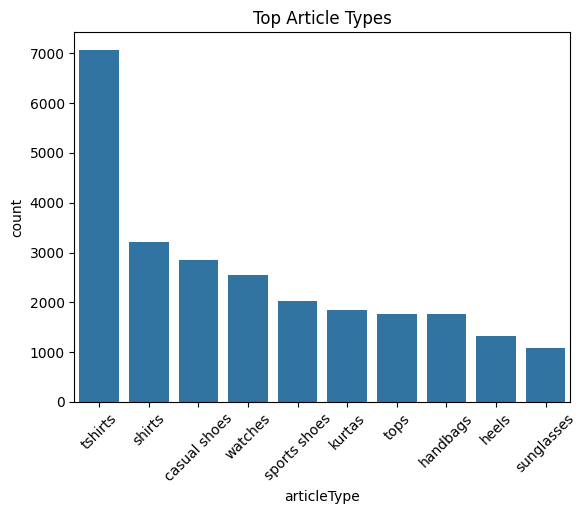

In [ ]:
sns.countplot(data=df, x='articleType', order=df['articleType'].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title("Top Article Types")
plt.show()


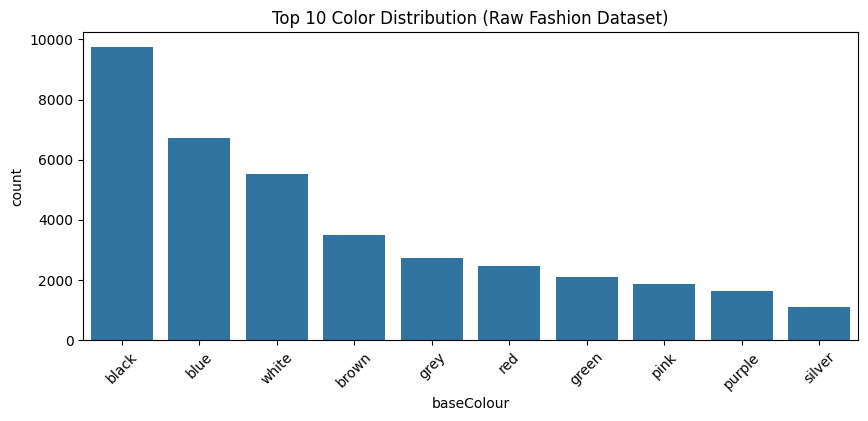

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='baseColour', order=df['baseColour'].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title("Top 10 Color Distribution (Raw Fashion Dataset)")
plt.show()


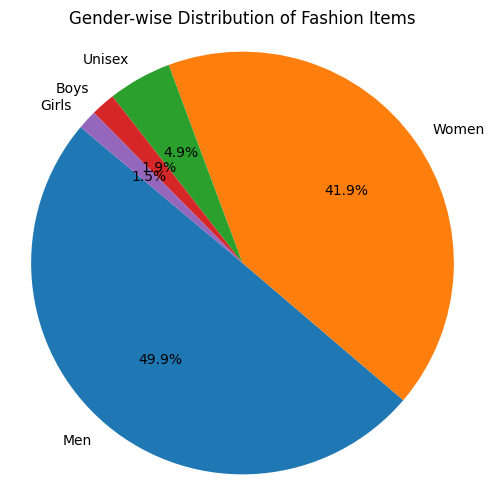

In [ ]:
import matplotlib.pyplot as plt

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Gender-wise Distribution of Fashion Items")
plt.axis('equal')
plt.show()



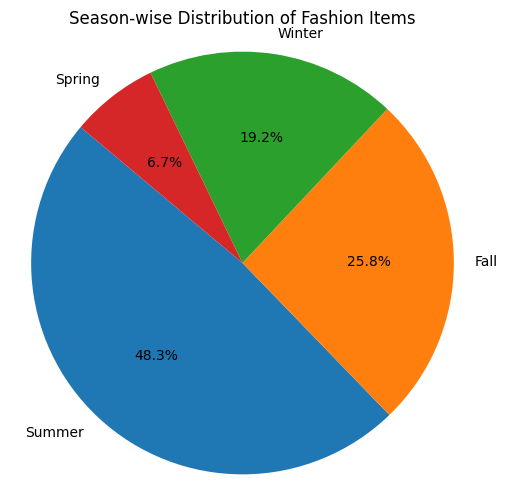

In [ ]:
season_counts = df['season'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    season_counts,
    labels=season_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Season-wise Distribution of Fashion Items")
plt.axis('equal')
plt.show()


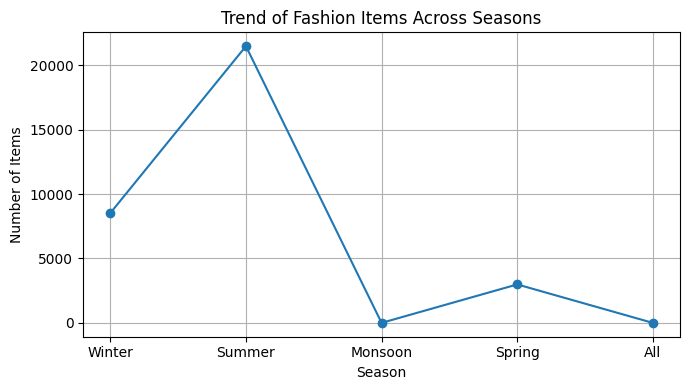

In [ ]:
import matplotlib.pyplot as plt

season_order = ['Winter', 'Summer', 'Monsoon', 'Spring', 'All']

season_counts = (
    df['season']
    .value_counts()
    .reindex(season_order)
    .fillna(0)
)

plt.figure(figsize=(7,4))
plt.plot(
    season_counts.index,
    season_counts.values,
    marker='o'
)

plt.title("Trend of Fashion Items Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Items")
plt.grid(True)
plt.tight_layout()
plt.show()


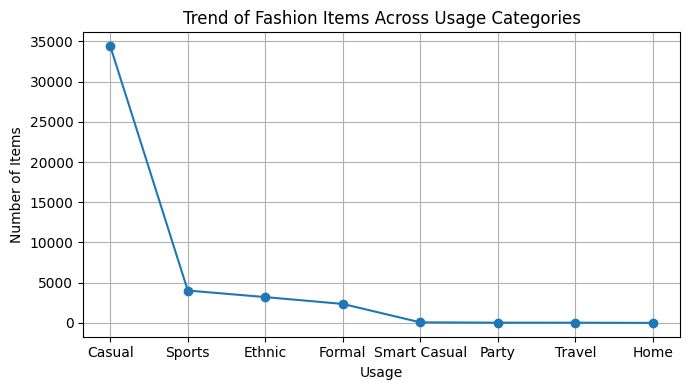

In [ ]:
usage_counts = df['usage'].value_counts()

plt.figure(figsize=(7,4))
plt.plot(
    usage_counts.index,
    usage_counts.values,
    marker='o'
)

plt.title("Trend of Fashion Items Across Usage Categories")
plt.xlabel("Usage")
plt.ylabel("Number of Items")
plt.grid(True)
plt.tight_layout()
plt.show()


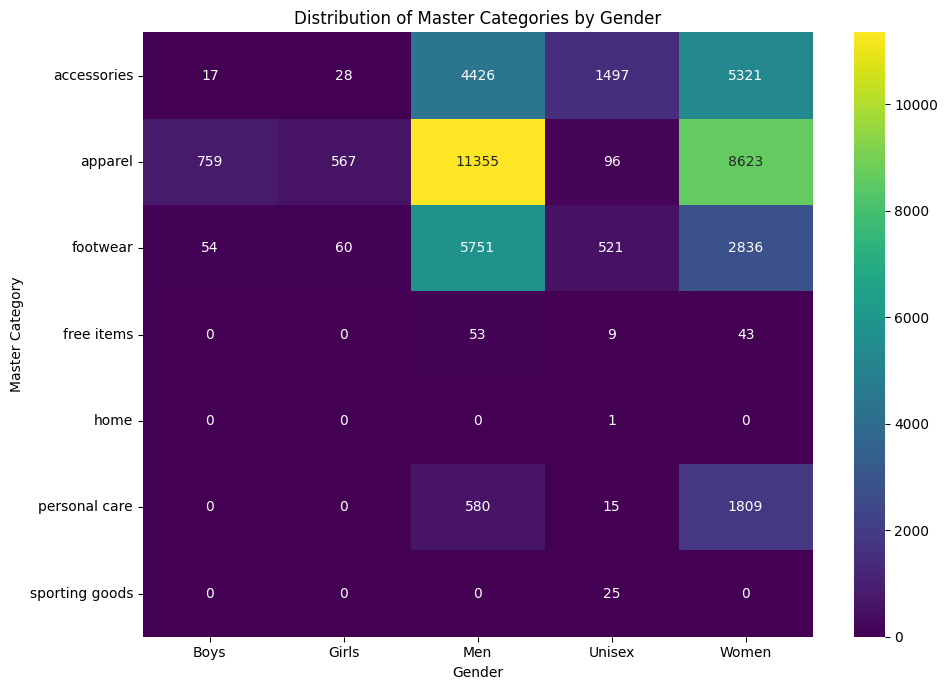

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a cross-tabulation (pivot table) to count occurrences of masterCategory per gender
df_crosstab = pd.crosstab(df['masterCategory'], df['gender'])

plt.figure(figsize=(10, 7))
sns.heatmap(df_crosstab, annot=True, fmt='d', cmap='viridis')
plt.title('Distribution of Master Categories by Gender')
plt.xlabel('Gender')
plt.ylabel('Master Category')
plt.tight_layout()
plt.show()

#Image linking


In [ ]:
df.columns


Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'usage', 'articleType_enc', 'baseColour_enc'],
      dtype='object')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/Stylo_dataset/images.zip \
      -d /content/drive/MyDrive/Stylo_dataset/images


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58128.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58129.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/5813.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58131.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58132.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58133.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58135.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58136.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58137.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58138.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/58139.jpg  
  inflating: /content/drive/MyDrive/Stylo_dataset/images/images/5814.jpg  
  inflating: /content/drive/MyDrive/Sty

In [ ]:
!ls /content/drive/MyDrive/Stylo_dataset/images/images | head


10000.jpg
10001.jpg
10002.jpg
10003.jpg
10004.jpg
10005.jpg
10006.jpg
10007.jpg
10008.jpg
10009.jpg


Add 'image_path' Column to Dataset

In [ ]:
df['image_path'] = df['id'].astype(str).apply(
    lambda x: f"/content/drive/MyDrive/images/{x}.jpg"
)


In [ ]:
import os

df['image_exists'] = df['image_path'].apply(os.path.exists)

df['image_exists'].value_counts()


,count
image_exists,
False,44446


In [ ]:
import os

image_dir = "/content/drive/MyDrive/Stylo_dataset/images/images"
image_files = os.listdir(image_dir)

image_files[:10]


['10000.jpg',
 '10001.jpg',
 '10002.jpg',
 '10003.jpg',
 '10004.jpg',
 '10005.jpg',
 '10006.jpg',
 '10007.jpg',
 '10008.jpg',
 '10009.jpg']

In [ ]:
df.head()


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,articleType_enc,baseColour_enc,image_path,image_exists
0,15970,Men,apparel,Topwear,shirts,blue,Fall,Casual,104,2,/content/drive/MyDrive/images/15970.jpg,False
1,39386,Men,apparel,Bottomwear,jeans,blue,Summer,Casual,56,2,/content/drive/MyDrive/images/39386.jpg,False
2,59263,Women,accessories,Watches,watches,silver,Winter,Casual,140,36,/content/drive/MyDrive/images/59263.jpg,False
3,21379,Men,apparel,Bottomwear,track pants,black,Fall,Casual,128,1,/content/drive/MyDrive/images/21379.jpg,False
4,53759,Men,apparel,Topwear,tshirts,grey,Summer,Casual,134,13,/content/drive/MyDrive/images/53759.jpg,False


In [ ]:
df['image_path'] = df['id'].astype(str).apply(
    lambda x: f"{image_dir}/{x}.jpg"
)


In [ ]:
df['image_exists'] = df['image_path'].apply(os.path.exists)
df['image_exists'].value_counts()


,count
image_exists,
True,44441
False,5


drop mismatched / broken rows


In [ ]:
df = df[df['image_exists']]
df.drop(columns=['image_exists'], inplace=True)


#cleaned dataset ready

In [ ]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,articleType_enc,baseColour_enc,image_path
0,15970,Men,apparel,Topwear,shirts,blue,Fall,Casual,104,2,/content/drive/MyDrive/Stylo_dataset/images/im...
1,39386,Men,apparel,Bottomwear,jeans,blue,Summer,Casual,56,2,/content/drive/MyDrive/Stylo_dataset/images/im...
2,59263,Women,accessories,Watches,watches,silver,Winter,Casual,140,36,/content/drive/MyDrive/Stylo_dataset/images/im...
3,21379,Men,apparel,Bottomwear,track pants,black,Fall,Casual,128,1,/content/drive/MyDrive/Stylo_dataset/images/im...
4,53759,Men,apparel,Topwear,tshirts,grey,Summer,Casual,134,13,/content/drive/MyDrive/Stylo_dataset/images/im...


In [ ]:
df.to_csv('cleaned_stylo_dataset.csv', index=False)


In [ ]:
from google.colab import files
files.download('cleaned_stylo_dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>